**Master Universitario en Bioinformática y Biología Computacional, UAM**
## **Minería de texto 2025-26**
# **Práctica de laboratorio 2: Word embeddings**

---

_Aviso_: algunas de las explicaciones y ejemplos de este notebook proceden de [Documentación de GenSim en NLTK](https://www.nltk.org/howto/gensim.html)

Antes de comenzar a trabajar, debemos configurar el entorno: 
- NLTK
- GenSim: permite trabajar con embeddings de palabras empleando Word2Vec, FastText y Doc2Vec.

Si no lo tenemos ya instalado, instalemos NLTK:

!pip install nltk

Ahora instalemos GenSim para poder trabajar con Word2Vec:

!pip install gensim

In [269]:
from nltk.test.gensim_fixt import setup_module
setup_module() # Puede que antes tengamos que ejecutar: !pip install pytest

Si no está ya instalado, descarguemos el corpus Brown de entre los disponibles en NLTK. Este es un corpus en inglés creado en 1961 en la Universidad de Brown. Cuenta con un millón de palabras con texto de 500 fuentes (noticias, editorial, etc.)

In [270]:
import nltk
nltk.download('brown')

[nltk_data] Downloading package brown to /home/enrijuliav/nltk_data...
[nltk_data]   Package brown is already up-to-date!


True

Para probar, nos bastará con tomar 10000 oraciones del corpus.

In [271]:
from nltk.corpus import brown
train_set = brown.sents()[:10000]

Entrenamos el modelo empleando el Word2Vec de GenSim:

In [272]:
import gensim
model = gensim.models.Word2Vec(train_set)

Si se usa un corpus muy grande, puede llevar mucho tiempo entrenarlo. Lo más cómodo en esos casos es guardarlo y volver a cargarlo:
model.save('brown.embedding') # para guardarlo
model = gensim.models.Word2Vec.load('brown.embedding') # para recuperarlo

Veamos cuántas palabras contiene el modelo:

In [273]:
model.corpus_total_words

219770

¿Cuáles son las 100 palabras más frecuentes?

In [274]:
model.wv.index_to_key[:100]

['the',
 ',',
 '.',
 'of',
 'and',
 'to',
 'a',
 'in',
 'is',
 'that',
 'for',
 '``',
 'The',
 "''",
 'was',
 'as',
 'on',
 'with',
 'be',
 'it',
 'by',
 'at',
 'he',
 'his',
 'are',
 ';',
 'not',
 'has',
 'from',
 'have',
 'this',
 'will',
 'an',
 '--',
 'which',
 'who',
 '?',
 'or',
 'but',
 'had',
 'would',
 'I',
 'one',
 'said',
 'were',
 'they',
 'all',
 'been',
 'their',
 'more',
 'its',
 ':',
 ')',
 '(',
 'He',
 'Mr.',
 'we',
 'than',
 'out',
 'It',
 'In',
 'up',
 'But',
 'there',
 'other',
 'when',
 'can',
 'no',
 'about',
 'only',
 'first',
 'new',
 'him',
 'A',
 'into',
 'so',
 'last',
 'Mrs.',
 'two',
 'some',
 'them',
 'what',
 'time',
 'her',
 'do',
 'any',
 'our',
 'man',
 'most',
 'also',
 'years',
 'could',
 'over',
 'year',
 'may',
 'New',
 'made',
 'if',
 'you',
 'American']

Una vez entrenado, el modelo contendrá la lista de palabras en el vocabulario del corpus procesado, junto con el embedding correspondiente para cada palabra.

Puede obtenese el embedding de una palabra accediendo al diccionario `wv` (word vector) que tiene el modelo.

In [275]:
model.wv['university']

array([-0.03750161, -0.02959517,  0.04599469, -0.1227194 , -0.01197416,
       -0.3793952 ,  0.12916525,  0.39833796, -0.00201852, -0.2971889 ,
       -0.05841663, -0.29606032, -0.1567807 ,  0.2553818 ,  0.01257383,
       -0.06038693,  0.05083132, -0.19895422,  0.04808074, -0.30425298,
        0.08813781,  0.15719758,  0.37237173, -0.20821334,  0.02570771,
       -0.04859737, -0.14490709,  0.00426338, -0.15716116, -0.00572889,
        0.1297019 , -0.07611402,  0.08254806, -0.20088863, -0.12299536,
        0.12014166,  0.08241254, -0.16389988, -0.2446852 , -0.1425522 ,
        0.10263553, -0.14743645, -0.20265236,  0.01358373,  0.07976047,
       -0.11571971, -0.25372607, -0.0252839 ,  0.15249717,  0.08876017,
       -0.00689526, -0.20293197,  0.06701615,  0.00181436,  0.00870595,
        0.12619232,  0.18858989, -0.11614823, -0.16958134,  0.03920742,
        0.00408555,  0.12500939,  0.10471774,  0.07070228, -0.14659514,
        0.3198736 , -0.08598139,  0.2229476 , -0.14873663,  0.03

y para calcular la similitud empleando la distancia coseno entre palabras:

In [276]:
model.wv.similarity('university','school')

np.float32(0.9938189)

Usando un modelo preentrenado. Podemos descargarlo, o emplear uno de los que tiene nltk:

In [277]:
nltk.download('word2vec_sample')

[nltk_data] Downloading package word2vec_sample to
[nltk_data]     /home/enrijuliav/nltk_data...
[nltk_data]   Package word2vec_sample is already up-to-date!


True

Ahora podemos cargarlo:

In [278]:
from nltk.data import find

# fichero con los vectores en formato texto
word2vec_sample = str(find('models/word2vec_sample/pruned.word2vec.txt'))
model = gensim.models.KeyedVectors.load_word2vec_format(word2vec_sample, binary=False)

Veamos cuáles son las 3 palabras más cercanas a 'university':

In [279]:
model.most_similar(positive=['university'], topn = 3)

[('universities', 0.7003918290138245),
 ('faculty', 0.6780906915664673),
 ('undergraduate', 0.6587096452713013)]

Obtenemos el vector de una palabra. Esta vez accesible directamente desde el modelo.

In [280]:
model['queen']

array([ 0.00173332, -0.0474043 , -0.022896  ,  0.0407935 ,  0.0435346 ,
       -0.0293455 , -0.0235409 , -0.0715902 , -0.0651406 ,  0.0183813 ,
       -0.0249921 , -0.125767  ,  0.0343439 , -0.00026957,  0.043857  ,
        0.0372462 ,  0.0240246 , -0.015479  ,  0.0217673 ,  0.0311192 ,
        0.0628833 ,  0.045147  , -0.0780398 , -0.0391811 ,  0.021606  ,
       -0.0175751 , -0.101903  ,  0.030313  ,  0.0622383 , -0.0551438 ,
       -0.0515965 , -0.0432121 , -0.0272494 ,  0.0703003 , -0.117382  ,
       -0.0435346 ,  0.0317641 ,  0.0870691 , -0.0312804 ,  0.0606259 ,
        0.0353114 , -0.137376  ,  0.089004  , -0.00915032,  0.0580461 ,
       -0.0372462 , -0.00136046,  0.0480493 ,  0.0515965 ,  0.0883591 ,
       -0.00592554,  0.0325703 ,  0.0174944 , -0.0103193 , -0.0538539 ,
       -0.0191875 , -0.113512  , -0.0570787 ,  0.03773   , -0.0298292 ,
        0.044502  ,  0.0922288 , -0.0164464 ,  0.0428896 ,  0.0580461 ,
       -0.0732026 , -0.0039302 ,  0.0464369 , -0.059981  ,  0.03

Juguemos un poco...

¿cuál es la palabra que no encaja en una lista dada?

In [281]:
model.doesnt_match(['breakfast', 'cereal', 'dinner', 'lunch'])

'cereal'

¿qué vector sale si hacemos `'woman'+'king'-'man'`?

In [282]:
model.most_similar(positive=['woman','king'], negative=['man'], topn = 1)

[('queen', 0.7118193507194519)]

¿y qué saldrá de la operación `man + daughter - woman`?

In [283]:
model.most_similar(positive=['man', 'daughter'], negative=['woman'], topn=1)

[('son', 0.8490633368492126)]

Ojo, lo que nos devuelve es el vector más próximo. Si, por ejemplo, queremos sacar los 3 vectores más próximos:

In [284]:
model.most_similar(positive=['woman','king'], negative=['man'], topn = 3)

[('queen', 0.7118193507194519),
 ('monarch', 0.6189674139022827),
 ('princess', 0.5902431011199951)]

Podemos explorar más ejemplos para obtener analogías semánticas menos evidentes.

In [285]:
analogias = [
    (['Paris','Japan'], ['France']),
    (['teacher','hospital'], ['school'])
]

for pos, neg in analogias:
    print(pos, '-', neg, '→', model.most_similar(positive=pos, negative=neg, topn=3))

['Paris', 'Japan'] - ['France'] → [('Tokyo', 0.814285933971405), ('Osaka', 0.6350962519645691), ('Seoul', 0.6054925918579102)]
['teacher', 'hospital'] - ['school'] → [('Hospital', 0.6331107020378113), ('nurse', 0.6280134320259094), ('doctor', 0.5242676734924316)]


### Ejercicio 1: Visualización de relaciones semánticas de embeddings mediante PCA

Usando el modelo Word2Vec previamente cargado, selecciona varios conjuntos de palabras que incluyan diferentes relaciones semánticas:
- Género de varias palabras: masculino, femenino
- Varios países y sus capitales
- Grados de varios adjetivos: positivo, comparativo, superlativo
- Palabras de la varias temáticas, p. ej., alimentos, medios de transporte, etc.

Reduce sus embeddings a dos dimensiones mediante PCA (Principal Component Analysis) y representa gráficamente las posiciones relativas de los embeddings de las palabras en el plano.

Observa si el modelo organiza de forma coherente las palabras; por ejemplo, king–queen vs. ..., Paris–France vs. ..., good–better–best vs. ..., apple-banana-grape vs. ....

##### Discute brevemente los resultados.

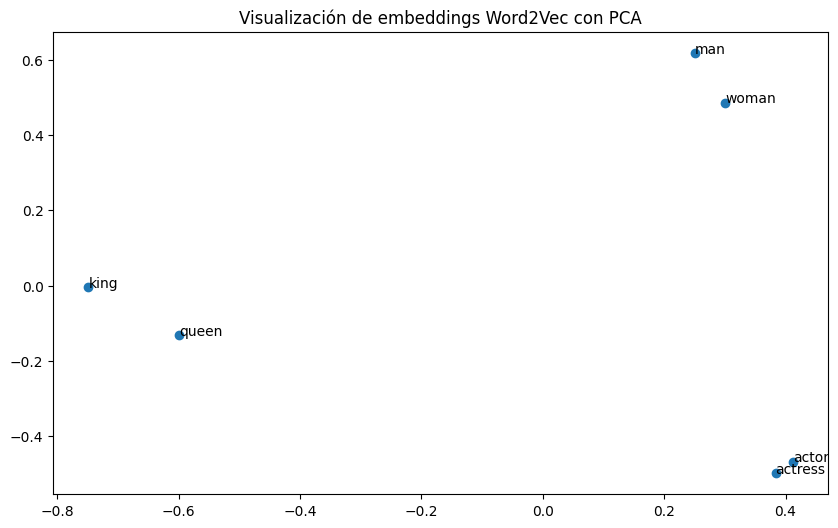

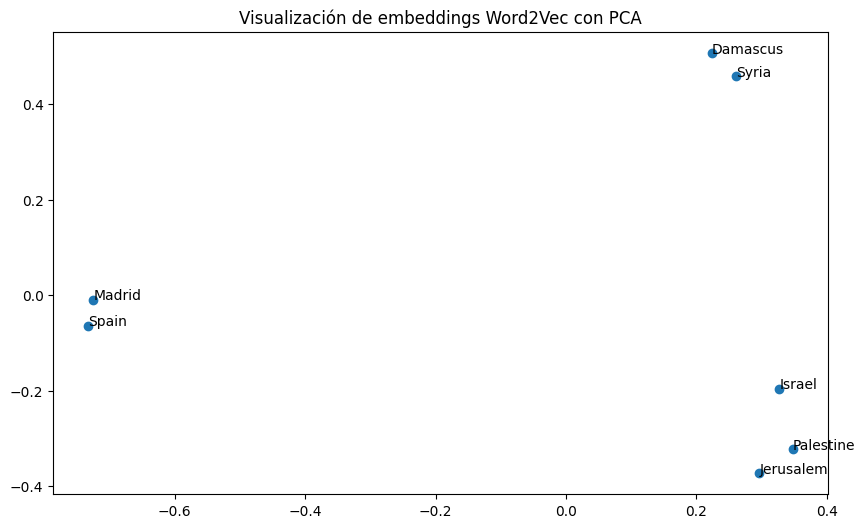

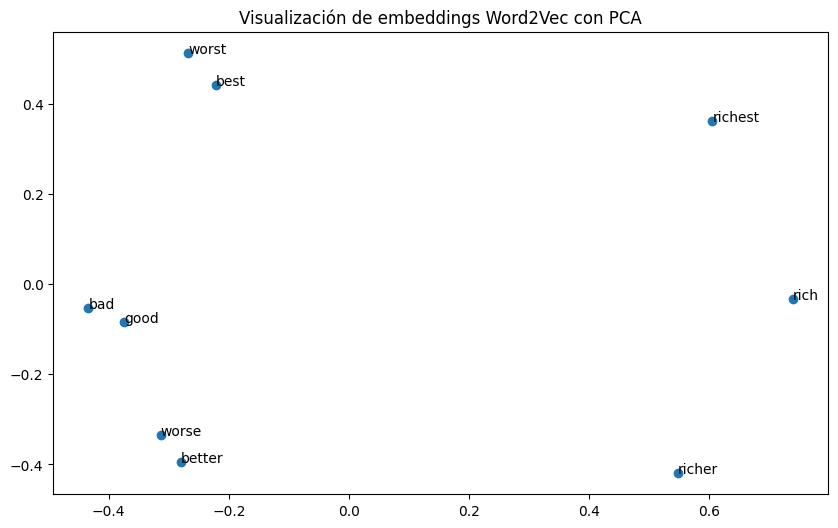

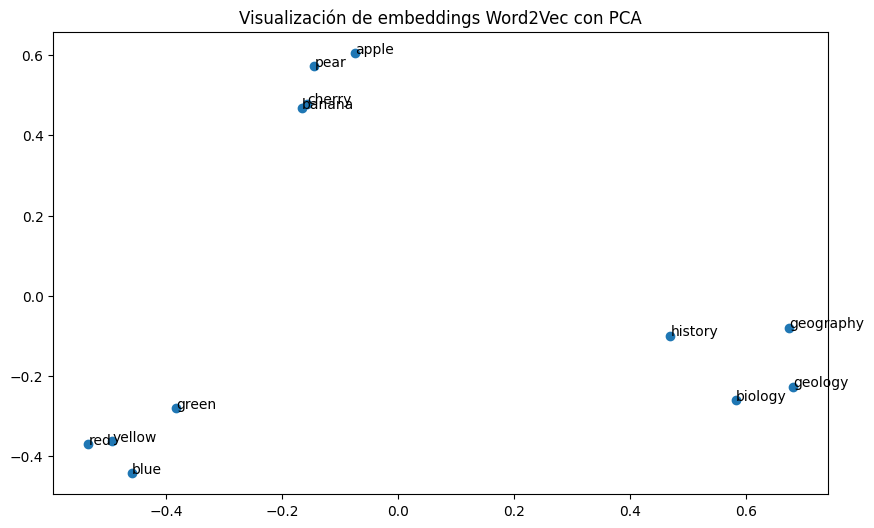

In [286]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# TO DO: establecer las palabras y obtener sus vectores (embeddings)
grupos=[["man","woman","king","queen", "actor","actress"],
        ["Spain","Madrid","Jerusalem","Palestine","Israel","Syria","Damascus"],
        ["bad","worse","worst","rich","richer","richest","good","better","best"],
        ["apple","banana","cherry","pear","blue","red","yellow","green","biology","geology","geography","history"]]

for palabras in grupos:
    vectores=[]
    for pal in palabras:
        vectores.append(model[pal])
    # Reducimos a 2D con PCA
    pca = PCA(n_components=2)
    coords = pca.fit_transform(vectores)

    # Visualización
    plt.figure(figsize=(10,6))
    plt.scatter(coords[:,0], coords[:,1])
    for i, palabra in enumerate(palabras):
        plt.annotate(palabra, (coords[i,0], coords[i,1]))
    plt.title("Visualización de embeddings Word2Vec con PCA")
    plt.show()


- **Género de varias palabras: masculino, femenino**

Si nos fijamos en los resultados, vemos como man y woman posee una relación bastante similar a king y queen, estando a unas distancias más o menos similares y manteniéndose paralelas. Sin embargo, al fijarnos en actor y actress, se puede ver como, no solo son mucho más similares que las otras palabras, sino que su relación no es paralela a las demás.

- **Varios países y sus capitales**

Observamos como todos los países están relacionados con sus capitales. Es verdad que Damasco-Siria tiene un ángulo diferente al resto, pero se pueden observar las relaciones. Además, por curiosidad, he decidido incluir las palabras Palestina-Jerusalen-Israel, para observar si la relación entre palabras mostraba algún sesgo. Como muestra la gráfica, se representa a Palestina como más relacionada con Jerusalen que Israel.

- **Grados de varios adjetivos: positivo, comparativo, superlativo**

Viendo los datos podemos extraer varias conclusiones. Vemos como los adjetivos antónimos good-bad y sus adjetivos graduados están muy relacionados, mientras que rich, está más separado. Además, vemos como se mantiene una relación entre todos los adjetivos, estando el adjetivo comparativo hacia abajo del base y, el superlativo, un poco más distante hacia arriba.

- **Palabras de la varias temáticas, p. ej., alimentos, medios de transporte, etc.**

Decidimos seleccionar tres temáticas diferentes: colores, frutas y asignaturas/campos de conocimiento. Observamos como las palabras se separan corectamente por clusters siguiendo sus temáticas. Además, podemos ver como hay grupos que están mucho más relacionados y ubicados cercanamente que otros, siendo las frutas las palabras más relacionadas y los campos de conocimiento, menos.

**Conclusión**

Observamos como el embedding aprende y mantiene estas relaciones entre palabras.

---------------------------


### Ejercicio 2: Valoración de sesgos en embeddings

Usando el modelo Word2Vec cargado, analiza posibles sesgos de género midiendo qué tan similares son ciertas profesiones a las palabras "man" y "woman".

Selecciona una lista de profesiones (p. ej., "doctor", "nurse", "engineer", "teacher", "secretary", "scientist", "housekeeper") y calcula su similitud con ambas palabras.

Observa si el modelo asocia algunas profesiones más fuertemente con "man" o con "woman", lo que podría indicar un sesgo aprendido a partir del corpus de entrenamiento.

##### Discute brevemente los resultados.

In [287]:
# Lista de profesiones a evaluar
profesiones = ['doctor', 'nurse', 'engineer', 'teacher', 'secretary', 'scientist', 'housekeeper']

# TO DO: comparar las similitudes de cada profesión con 'man' y 'woman'
for profesion in profesiones:
    man=model.similarity("man",profesion)
    woman=model.similarity("woman",profesion)
    print(f"Profesión: {profesion}\t-> Hombre: {man:.5f} - Mujer: {woman:.5f} - Diferencia: {(man-woman):.2f}\t- Proporción(H/M): {man/woman:.2f}")

Profesión: doctor	-> Hombre: 0.31449 - Mujer: 0.37946 - Diferencia: -0.06	- Proporción(H/M): 0.83
Profesión: nurse	-> Hombre: 0.25472 - Mujer: 0.44136 - Diferencia: -0.19	- Proporción(H/M): 0.58
Profesión: engineer	-> Hombre: 0.15129 - Mujer: 0.09435 - Diferencia: 0.06	- Proporción(H/M): 1.60
Profesión: teacher	-> Hombre: 0.25000 - Mujer: 0.31358 - Diferencia: -0.06	- Proporción(H/M): 0.80
Profesión: secretary	-> Hombre: 0.04002 - Mujer: 0.09049 - Diferencia: -0.05	- Proporción(H/M): 0.44
Profesión: scientist	-> Hombre: 0.15825 - Mujer: 0.15487 - Diferencia: 0.00	- Proporción(H/M): 1.02
Profesión: housekeeper	-> Hombre: 0.33342 - Mujer: 0.47662 - Diferencia: -0.14	- Proporción(H/M): 0.70


Se observa que, por lo general, cada una de las profesiones está más sesgada hacia un género, salvo, curiosamente, la profesión de cientifica.

Este sesgo es extremadamente evidente en los casos de las profesiones de secretaria y enfermera, muy sesgadas hacia las mujeres, y la profesión de ingeniero, muy sesgado hacia los hombres.

Otra observación curiosa es que, salvo la profesión de ingeniero, el resto están sesgadas hacia las mujeres. Esto sorprende sobre todo en el caso de las médicas. Podemos suponer que, el embedding y sus textos de aprendizaje, están reflejando la feminización del campo de la salud.

---------------------------

### Ejercicio 3: Representación de una oración mediante un embedding

Implementa una función `embedding_oracion` que obtenga el vector representativo de una oración calculando el promedio (p. ej., usando `mean` de `numpy`) de los embeddings de sus palabras.

Usa esta función para comparar varias oraciones y medir su similitud semántica mediante la distancia coseno (`model.cosine_similarities`) entre sus embeddings.

Observa si oraciones con significados parecidos (p. ej., "The cat sat on the mat" y "A dog rested on the rug") presentan una similitud mayor que las que hablan de temas distintos (p. ej., "I like pizza and pasta").

##### Discute brevemente los resultados.

In [288]:
import numpy as np
oracion = "The cat sat on the mat"
palabras = oracion.split()
embeddings = []
for palabra in palabras:
    embeddings.append(model[palabra])


In [296]:
import numpy as np

def embedding_oracion(oracion):
    palabras = oracion.split()
    embeddings = []
    for palabra in palabras:
        embeddings.append(model[palabra])
    return np.mean(embeddings, axis=0)


o1 = "The cat sat on the mat"
o2 = "A dog rested on the rug"
o3 = "I like pizza with pineapple"

sim_1_2 = model.cosine_similarities(embedding_oracion(o1), [embedding_oracion(o2)])[0]
sim_1_3 = model.cosine_similarities(embedding_oracion(o1), [embedding_oracion(o3)])[0]

print(f"Similitud o1-o2: {sim_1_2:.3f}")
print(f"Similitud o1-o3: {sim_1_3:.3f}")

Similitud o1-o2: 0.831
Similitud o1-o3: 0.373


Nos da error debido a que las dos últimas palabras de la oración 3 (*and pasta*) no están contenidas en nuestro embedding, por lo que sustituiremos algunas palabras para evitar que nos de error y podamos ver la similitud entre oraciones. Sustituiremos *and pasta* con *with pineapple*.

Al realizar estos cambios vemos como la similitud entre las dos primeras oraciones es bastante mayor a la de la primera y la última oración, lo que tiene mucho sentido al hablar unas de mascotas descansando y otra de comida. De esta manera podemos afirmar que estos embeddings de oraciones codifican para la información de la frase de alguna manera, permitiendo observar propiedades, como su similitud, de manera efectiva.

--------------

### Ejercicio 4: Medida de la coherencia semántica de una oración

Implementa una función `coherencia_oracion` que calcule la coherencia semántica de una oración midiendo la similitud promedio entre los embeddings de palabras consecutivas.

Aplica la función a oraciones con sentido ("the cat sat on the mat") y a oraciones absurdas ("the banana drove a spaceship") para observar cómo varía el nivel de coherencia calculado por el modelo.

##### Discute brevemente los resultados.

In [302]:
def coherencia_oracion(oracion):
    palabras = oracion.split()
    similaridad = []
    for ventana in range(len(palabras)-1):
        similaridad.append(model.similarity(palabras[ventana],palabras[ventana+1]))
    return np.mean(similaridad)

print(coherencia_oracion("the cat sat on the mat"))
print(coherencia_oracion("the banana drove one spaceship"))

0.16308203
0.09433676


Nos da error debido a que la palabra *a* de la segunda oración no está contenida en nuestro embedding, por lo que la sustituiremos para evitar que nos de error y podamos ver la coherencia de las oraciones. Sustituiremos *a* con *one*.

Al observar los resultados vemos como la primera oración tiene una puntuación de coherencia mayor a la segunda. Esto tiene bastante sentido, ya que la coherencia requeire que tenga palabras consecutivas más relacionadas entre ellas.

De esta manera, con las características encapsuladas por el embedding podemos también medir métricas como la coherencia.

---------------

### Ejercicio 5: Análisis de la reciprocidad entre vecinos semánticos

Implementa una función `vecinos_reciprocos` que evalúe si la relación de similitud entre palabras es recíproca: es decir, si una palabra A considera a B como uno de sus vecinos más cercanos, y B también considera a A dentro de sus vecinos.

Aplica esta función a varias palabras y calcula el porcentaje de vecinos recíprocos para cada una.

##### Reflexiona sobre los resultados y qué pueden revelar acerca de la estructura del espacio de embeddings y las asimetrías en las relaciones de similitud.

In [303]:
def vecinos_reciprocos(palabra, topn=5):
    vecinos = model.most_similar(positive=[palabra], topn=topn)
    coincidencias = 0
    for vecino in vecinos:
        inversos = model.most_similar(positive=[vecino], topn=5)
        coincidencias +=  sum([bool(palabra in inverso) for inverso in inversos])
    return coincidencias/topn

for w in ['king', 'dog', 'music']:
    print(f"{w}: {vecinos_reciprocos(w)*100:.1f}% de vecinos son recíprocos")

king: 100.0% de vecinos son recíprocos
dog: 100.0% de vecinos son recíprocos
music: 40.0% de vecinos son recíprocos


Como muestran los resultados, al mirar los 5 vecinos más cercanos de estas palabras, tanto *king* como *dog* presentan un 100% de vecinos recíprocos. Sin embargo, *music* solo tiene un 40% de vecinos recíprocos.

Si tuviera que darle una explicación a este resultado, argumentaría que se debe a las relaciones entre palabras que capturan los embeddings. Al final las palabras *king* y *dog* son palabras con un significado muy concreto con unos pocos sinónimos y palabras relacionadas muy concisas y definidas. Sin embargo, la palabra music es mucho más conceptual, lo que permite que se relacione con muchas palabras diferentes y que no tenga una relaciones tan concisas y definidas.

Esto implica que los embeddings son capaces de almacenar y codificar asimetrías entre las relaciones de palabras, teniendo en cuenta sus apariciones, se ve como hay palabras que son más importantes que otras y como eso afecta de manera desigual a sus relaciones.

---------------